
# Forecast Hourly Bike Rentals

## Overview

Building upon the previous capstone work, which focused on data aggregation, cleaning, processing, and visualization, this phase aims to develop machine learning models to predict hourly bike rental counts. The project will cover feature engineering, scaling, and regression modeling techniques to build an effective predictive model.

## Project Statement

Develop an end-to-end machine learning pipeline to forecast hourly bike rentals using various regression techniques and performance evaluation methods

## Input dataset link: [Dataset](https://drive.google.com/drive/folders/1RFvzO7Eyidp4M9GCSO93izHXnaBFfQbF?usp=drive_link)


| Data Variable           | Description                                                  |
|-------------------------|:-------------------------------------------------------------|
| Date                    | Date in year-month-day format                                |
| Dew_point_temperatureC  | Dew point temperature in Celsius                             |
| Functioning_Day         | Bike rented during functional (Fun) and nonfunctional hour   |
| Holiday                 | Is it a holiday? Holiday/ No holiday                         |
| Hour                    | Hour of the day                                              |
| HumidityPct             | Humidity in percentage                                       |
| Rainfallmm              | Rainfall in mm                                               |
| Rented_Bike_Count       | Count of bikes rented each hour                              |
| Seasons                 | Season of the year - Winter, Summary, Spring, and Fall       |
| Snowfall_cm             | Snowfall in cm                                               |
| Solar_Radiation_MJ_m2   | Radient energy from the sun measured in MJ/m2                |
| TemperatureC            | Temperature in Celsius                                       |
| Visibility_10m          | Visibility in meters                                         |
| Wind_speed_m_s          | Speed of the wind in meters per sec (m/s)s (NoFunc)          |



## Steps to Perform

### Task 1: Feature engineering (45 mins)
1. Analyze the provided dataset and select relevant features
2. Create new features such as:
     - Interaction features
3. Encode categorical variables and handle missing values
4. Scale the numerical features using StandardScaler
5. Save the processed dataset as "bike_rental_features.csv"

### Task 2: Model building (75 mins)
1. Implement various regression models including:
    - Linear Regression
    - Ridge Regression (L2 Regularization)
    - Lasso Regression (L1 Regularization)
    - Elastic Net Regression
2. Perform hyperparameter tuning using GridSearchCV
3. Evaluate model performance using:
    - Mean Absolute Error (MAE)
    - Mean Squared Error (MSE)
    - R-squared (R²)

### Task 3: Model building with polynomial features (45 mins)
1. Create polynomial features for selected numerical columns
2. Train models with polynomial features to capture non-linear relationships
3. Compare results with linear models to assess improvements
4. Save the best-performing model

### Task 4: Model evaluation and validation (45 mins)
1. Perform cross-validation techniques to validate model performance (on both models- With Polynomial Features and without Polynomial Features)
2. Assess models using test data
3. Compare results across different regression models

### Task 5: Reporting and insights (30 mins)
1.    Summarize findings and key takeaways from the analysis
2.    Discuss feature importance and business implications
3.    Provide recommendations for further improvements

### Task 1: Feature engineering (45 mins)
1. Analyze the provided dataset and select relevant features
2. Create new features such as:
     - Interaction features
3. Encode categorical variables and handle missing values
4. Scale the numerical features using StandardScaler
5. Save the processed dataset as "bike_rental_features.csv"

# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Data Loading and Cleaning

In [4]:
df = pd.read_csv('FloridaBikeRentals.csv', encoding='latin-1')

df.columns = (df.columns
               .str.replace('(', '', regex=False)
               .str.replace(')', '', regex=False)
               .str.replace('°C', 'C', regex=False)
               .str.replace('%', 'Pct', regex=False)
               .str.replace(' ', '_', regex=False)
               .str.replace('/', '_', regex=False))

print("\nColumn names after cleaning:")
print(df.columns.tolist())


Column names after cleaning:
['Date', 'Rented_Bike_Count', 'Hour', 'TemperatureC', 'HumidityPct', 'Wind_speed_m_s', 'Visibility_10m', 'Dew_point_temperatureC', 'Solar_Radiation_MJ_m2', 'Rainfallmm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day']


In [5]:

print("Dataset shape:", df.shape)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Handle missing values (if any)
df = df.dropna()

# Explore the data
print(df.head())
print(df.info())
print(df.describe())

df

Dataset shape: (8760, 14)

Missing values:
Date                      0
Rented_Bike_Count         0
Hour                      0
TemperatureC              0
HumidityPct               0
Wind_speed_m_s            0
Visibility_10m            0
Dew_point_temperatureC    0
Solar_Radiation_MJ_m2     0
Rainfallmm                0
Snowfall_cm               0
Seasons                   0
Holiday                   0
Functioning_Day           0
dtype: int64
         Date  Rented_Bike_Count  Hour  TemperatureC  HumidityPct  \
0  01-12-2017                254     0          -5.2           37   
1  01-12-2017                204     1          -5.5           38   
2  01-12-2017                173     2          -6.0           39   
3  01-12-2017                107     3          -6.2           40   
4  01-12-2017                 78     4          -6.0           36   

   Wind_speed_m_s  Visibility_10m  Dew_point_temperatureC  \
0             2.2            2000                   -17.6   
1             0

,Date,Rented_Bike_Count,Hour,TemperatureC,HumidityPct,Wind_speed_m_s,Visibility_10m,Dew_point_temperatureC,Solar_Radiation_MJ_m2,Rainfallmm,Snowfall_cm,Seasons,Holiday,Functioning_Day
0,01-12-2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01-12-2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01-12-2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01-12-2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01-12-2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30-11-2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30-11-2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30-11-2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30-11-2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


# Task 1: Feature Engineering

In [6]:

# Create interaction features
df['temp_humidity'] = df['TemperatureC'] * df['HumidityPct']
df['temp_windspeed'] = df['TemperatureC'] * df['Wind_speed_m_s']
df['temp_solar'] = df['TemperatureC'] * df['Solar_Radiation_MJ_m2']

# Encode categorical variables
# Note: Using drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=['Seasons', 'Holiday', 'Functioning_Day'], drop_first=True)

print("\nShape after encoding:", df_encoded.shape)
print("New columns:", [col for col in df_encoded.columns if col not in df.columns])

# Separate features and target
X = df_encoded.drop(['Rented_Bike_Count', 'Date'], axis=1)  # Drop target and date
y = df_encoded['Rented_Bike_Count']

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

# Split the data (80:20 ratio, random_state=42 for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame with column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Save processed data
X_train_scaled_df['Rented_Bike_Count'] = y_train.values
X_train_scaled_df.to_csv('bike_rental_features.csv', index=False)

print("\n✓ Feature engineering complete!")
print(f"✓ Training set: {X_train_scaled.shape[0]} samples")
print(f"✓ Test set: {X_test_scaled.shape[0]} samples")
print(f"✓ Saved to 'bike_rental_features.csv'")


Shape after encoding: (8760, 19)
New columns: ['Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter', 'Holiday_No Holiday', 'Functioning_Day_Yes']

Features shape: (8760, 17)
Target shape: (8760,)

✓ Feature engineering complete!
✓ Training set: 7008 samples
✓ Test set: 1752 samples
✓ Saved to 'bike_rental_features.csv'


# Task 2: Model Building

LINEAR REGRESSION
MAE: 318.77
MSE: 182345.43
RMSE: 427.02
R²: 0.5623

RIDGE REGRESSION (L2 Regularization)
Best alpha: 10
MAE: 318.85
MSE: 182440.03
RMSE: 427.13
R²: 0.5621

LASSO REGRESSION (L1 Regularization)
Best alpha: 0.1
MAE: 318.72
MSE: 182353.12
RMSE: 427.03
R²: 0.5623

ELASTIC NET REGRESSION
Best params: {'alpha': 0.001, 'l1_ratio': 0.2}
MAE: 318.81
MSE: 182393.70
RMSE: 427.08
R²: 0.5622

MODEL COMPARISON SUMMARY
            Model        MAE           MSE       RMSE       R²
Linear Regression 318.765272 182345.433249 427.019242 0.562350
            Ridge 318.851570 182440.030200 427.129992 0.562122
            Lasso 318.724672 182353.119082 427.028242 0.562331
      Elastic Net 318.808002 182393.699516 427.075754 0.562234


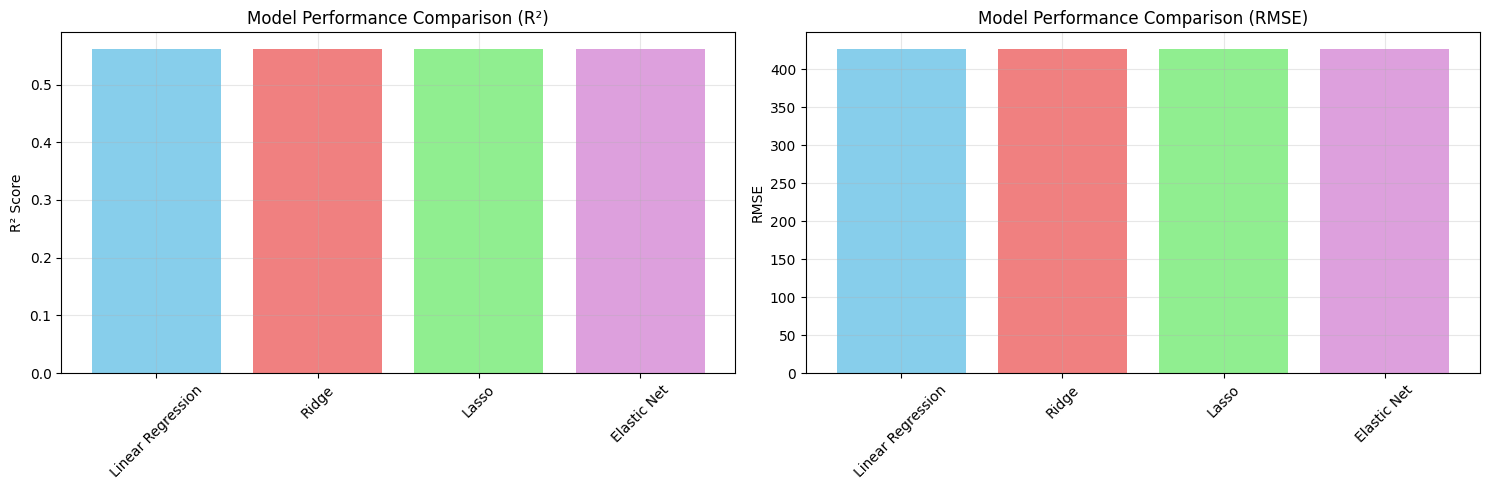

In [8]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Linear Regression
print("="*60)
print("LINEAR REGRESSION")
print("="*60)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print(f"MAE: {lr_mae:.2f}")
print(f"MSE: {lr_mse:.2f}")
print(f"RMSE: {np.sqrt(lr_mse):.2f}")
print(f"R²: {lr_r2:.4f}")

# 2. Ridge Regression with hyperparameter tuning
print("\n" + "="*60)
print("RIDGE REGRESSION (L2 Regularization)")
print("="*60)
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge = Ridge()
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)
ridge_pred = ridge_grid.predict(X_test_scaled)

print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f"MAE: {mean_absolute_error(y_test, ridge_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, ridge_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ridge_pred)):.2f}")
print(f"R²: {r2_score(y_test, ridge_pred):.4f}")

# 3. Lasso Regression
print("\n" + "="*60)
print("LASSO REGRESSION (L1 Regularization)")
print("="*60)
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
lasso = Lasso(max_iter=10000)
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)
lasso_pred = lasso_grid.predict(X_test_scaled)

print(f"Best alpha: {lasso_grid.best_params_['alpha']}")
print(f"MAE: {mean_absolute_error(y_test, lasso_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, lasso_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lasso_pred)):.2f}")
print(f"R²: {r2_score(y_test, lasso_pred):.4f}")

# 4. Elastic Net Regression
print("\n" + "="*60)
print("ELASTIC NET REGRESSION")
print("="*60)
elasticnet_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.2, 0.5, 0.8]
}
elasticnet = ElasticNet(max_iter=10000)
elasticnet_grid = GridSearchCV(elasticnet, elasticnet_params, cv=5, scoring='r2', n_jobs=-1)
elasticnet_grid.fit(X_train_scaled, y_train)
elasticnet_pred = elasticnet_grid.predict(X_test_scaled)

print(f"Best params: {elasticnet_grid.best_params_}")
print(f"MAE: {mean_absolute_error(y_test, elasticnet_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, elasticnet_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, elasticnet_pred)):.2f}")
print(f"R²: {r2_score(y_test, elasticnet_pred):.4f}")

# Compare all models
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

models_results = {
    'Linear Regression': {'pred': lr_pred, 'r2': lr_r2},
    'Ridge': {'pred': ridge_pred, 'r2': r2_score(y_test, ridge_pred)},
    'Lasso': {'pred': lasso_pred, 'r2': r2_score(y_test, lasso_pred)},
    'Elastic Net': {'pred': elasticnet_pred, 'r2': r2_score(y_test, elasticnet_pred)}
}

comparison_df = pd.DataFrame({
    'Model': list(models_results.keys()),
    'MAE': [mean_absolute_error(y_test, models_results[m]['pred']) for m in models_results],
    'MSE': [mean_squared_error(y_test, models_results[m]['pred']) for m in models_results],
    'RMSE': [np.sqrt(mean_squared_error(y_test, models_results[m]['pred'])) for m in models_results],
    'R²': [models_results[m]['r2'] for m in models_results]
})

print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot of R² scores
axes[0].bar(comparison_df['Model'], comparison_df['R²'], color=['skyblue', 'lightcoral', 'lightgreen', 'plum'])
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Performance Comparison (R²)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Bar plot of RMSE
axes[1].bar(comparison_df['Model'], comparison_df['RMSE'], color=['skyblue', 'lightcoral', 'lightgreen', 'plum'])
axes[1].set_ylabel('RMSE')
axes[1].set_title('Model Performance Comparison (RMSE)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Task 3: Polynomial Features

In [9]:
from sklearn.preprocessing import PolynomialFeatures
import joblib

print("="*60)
print("POLYNOMIAL FEATURES APPROACH")
print("="*60)

# Select key numerical features for polynomial transformation
# (Using all features might create too many features)
numerical_features = ['TemperatureC', 'HumidityPct', 'Wind_speed_m_s',
                      'Hour', 'Solar_Radiation_MJ_m2']

# Get indices of these columns in the scaled data
feature_indices = [X.columns.get_loc(col) for col in numerical_features if col in X.columns]

print(f"\nCreating polynomial features for: {numerical_features}")
print(f"Original features count: {X_train_scaled.shape[1]}")

# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform only selected features
X_train_poly = poly.fit_transform(X_train_scaled[:, feature_indices])
X_test_poly = poly.transform(X_test_scaled[:, feature_indices])

print(f"Polynomial features count: {X_train_poly.shape[1]}")

# Train models with polynomial features
print("\n" + "="*60)
print("LINEAR REGRESSION WITH POLYNOMIAL FEATURES")
print("="*60)
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
lr_poly_pred = lr_poly.predict(X_test_poly)

print(f"MAE: {mean_absolute_error(y_test, lr_poly_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, lr_poly_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_poly_pred)):.2f}")
print(f"R²: {r2_score(y_test, lr_poly_pred):.4f}")

print("\n" + "="*60)
print("RIDGE REGRESSION WITH POLYNOMIAL FEATURES")
print("="*60)
ridge_poly = Ridge(alpha=ridge_grid.best_params_['alpha'])
ridge_poly.fit(X_train_poly, y_train)
ridge_poly_pred = ridge_poly.predict(X_test_poly)

print(f"MAE: {mean_absolute_error(y_test, ridge_poly_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, ridge_poly_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ridge_poly_pred)):.2f}")
print(f"R²: {r2_score(y_test, ridge_poly_pred):.4f}")

# Compare linear vs polynomial
print("\n" + "="*60)
print("LINEAR vs POLYNOMIAL FEATURES COMPARISON")
print("="*60)

poly_comparison = pd.DataFrame({
    'Model': ['Linear - No Poly', 'Linear - With Poly', 'Ridge - No Poly', 'Ridge - With Poly'],
    'R²': [lr_r2, r2_score(y_test, lr_poly_pred),
           r2_score(y_test, ridge_pred), r2_score(y_test, ridge_poly_pred)],
    'RMSE': [np.sqrt(lr_mse), np.sqrt(mean_squared_error(y_test, lr_poly_pred)),
             np.sqrt(mean_squared_error(y_test, ridge_pred)),
             np.sqrt(mean_squared_error(y_test, ridge_poly_pred))]
})

print(poly_comparison.to_string(index=False))

# Save the best model
best_model = ridge_poly if r2_score(y_test, ridge_poly_pred) > r2_score(y_test, ridge_pred) else ridge_grid.best_estimator_
joblib.dump(best_model, 'best_poly_model.pkl')
joblib.dump(poly, 'polynomial_transformer.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"\n✓ Best model saved as 'best_poly_model.pkl'")
print(f"✓ Best model R²: {max(poly_comparison['R²']):.4f}")

POLYNOMIAL FEATURES APPROACH

Creating polynomial features for: ['TemperatureC', 'HumidityPct', 'Wind_speed_m_s', 'Hour', 'Solar_Radiation_MJ_m2']
Original features count: 17
Polynomial features count: 20

LINEAR REGRESSION WITH POLYNOMIAL FEATURES
MAE: 311.27
MSE: 190931.71
RMSE: 436.96
R²: 0.5417

RIDGE REGRESSION WITH POLYNOMIAL FEATURES
MAE: 311.26
MSE: 190888.64
RMSE: 436.91
R²: 0.5418

LINEAR vs POLYNOMIAL FEATURES COMPARISON
             Model       R²       RMSE
  Linear - No Poly 0.562350 427.019242
Linear - With Poly 0.541741 436.957337
   Ridge - No Poly 0.562122 427.129992
 Ridge - With Poly 0.541845 436.908042

✓ Best model saved as 'best_poly_model.pkl'
✓ Best model R²: 0.5623


# Task 4: Cross-Validation

In [10]:
from sklearn.model_selection import cross_val_score, cross_validate

print("="*60)
print("CROSS-VALIDATION ANALYSIS")
print("="*60)

# Define scoring metrics
scoring = ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']

# Models WITHOUT polynomial features
print("\n" + "="*60)
print("MODELS WITHOUT POLYNOMIAL FEATURES")
print("="*60)

models_no_poly = {
    'Linear Regression': lr_model,
    'Ridge': ridge_grid.best_estimator_,
    'Lasso': lasso_grid.best_estimator_,
    'Elastic Net': elasticnet_grid.best_estimator_
}

for name, model in models_no_poly.items():
    cv_results = cross_validate(model, X_train_scaled, y_train,
                                cv=5, scoring=scoring, n_jobs=-1)

    print(f"\n{name}:")
    print(f"  R² CV Score: {cv_results['test_r2'].mean():.4f} (+/- {cv_results['test_r2'].std():.4f})")
    print(f"  MAE CV Score: {-cv_results['test_neg_mean_absolute_error'].mean():.2f} "
          f"(+/- {cv_results['test_neg_mean_absolute_error'].std():.2f})")
    print(f"  RMSE CV Score: {np.sqrt(-cv_results['test_neg_mean_squared_error'].mean()):.2f}")

# Models WITH polynomial features
print("\n" + "="*60)
print("MODELS WITH POLYNOMIAL FEATURES")
print("="*60)

models_poly = {
    'Linear Regression (Poly)': lr_poly,
    'Ridge (Poly)': ridge_poly
}

for name, model in models_poly.items():
    cv_results = cross_validate(model, X_train_poly, y_train,
                                cv=5, scoring=scoring, n_jobs=-1)

    print(f"\n{name}:")
    print(f"  R² CV Score: {cv_results['test_r2'].mean():.4f} (+/- {cv_results['test_r2'].std():.4f})")
    print(f"  MAE CV Score: {-cv_results['test_neg_mean_absolute_error'].mean():.2f} "
          f"(+/- {cv_results['test_neg_mean_absolute_error'].std():.2f})")
    print(f"  RMSE CV Score: {np.sqrt(-cv_results['test_neg_mean_squared_error'].mean()):.2f}")

# Final test set evaluation
print("\n" + "="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)

# Test best model on test set
final_test_r2 = r2_score(y_test, ridge_poly_pred)
final_test_mae = mean_absolute_error(y_test, ridge_poly_pred)
final_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_poly_pred))

print(f"\nBest Model (Ridge with Polynomial Features):")
print(f"  Test R²: {final_test_r2:.4f}")
print(f"  Test MAE: {final_test_mae:.2f}")
print(f"  Test RMSE: {final_test_rmse:.2f}")

CROSS-VALIDATION ANALYSIS

MODELS WITHOUT POLYNOMIAL FEATURES

Linear Regression:
  R² CV Score: 0.5779 (+/- 0.0145)
  MAE CV Score: 312.53 (+/- 2.42)
  RMSE CV Score: 418.67

Ridge:
  R² CV Score: 0.5780 (+/- 0.0145)
  MAE CV Score: 312.47 (+/- 2.47)
  RMSE CV Score: 418.65

Lasso:
  R² CV Score: 0.5779 (+/- 0.0145)
  MAE CV Score: 312.50 (+/- 2.44)
  RMSE CV Score: 418.66

Elastic Net:
  R² CV Score: 0.5780 (+/- 0.0145)
  MAE CV Score: 312.49 (+/- 2.44)
  RMSE CV Score: 418.64

MODELS WITH POLYNOMIAL FEATURES

Linear Regression (Poly):
  R² CV Score: 0.5612 (+/- 0.0151)
  MAE CV Score: 306.35 (+/- 5.82)
  RMSE CV Score: 426.90

Ridge (Poly):
  R² CV Score: 0.5612 (+/- 0.0149)
  MAE CV Score: 306.34 (+/- 5.81)
  RMSE CV Score: 426.89

FINAL TEST SET EVALUATION

Best Model (Ridge with Polynomial Features):
  Test R²: 0.5418
  Test MAE: 311.26
  Test RMSE: 436.91


# Task 5: Reporting and Insights

FINAL REPORT AND INSIGHTS


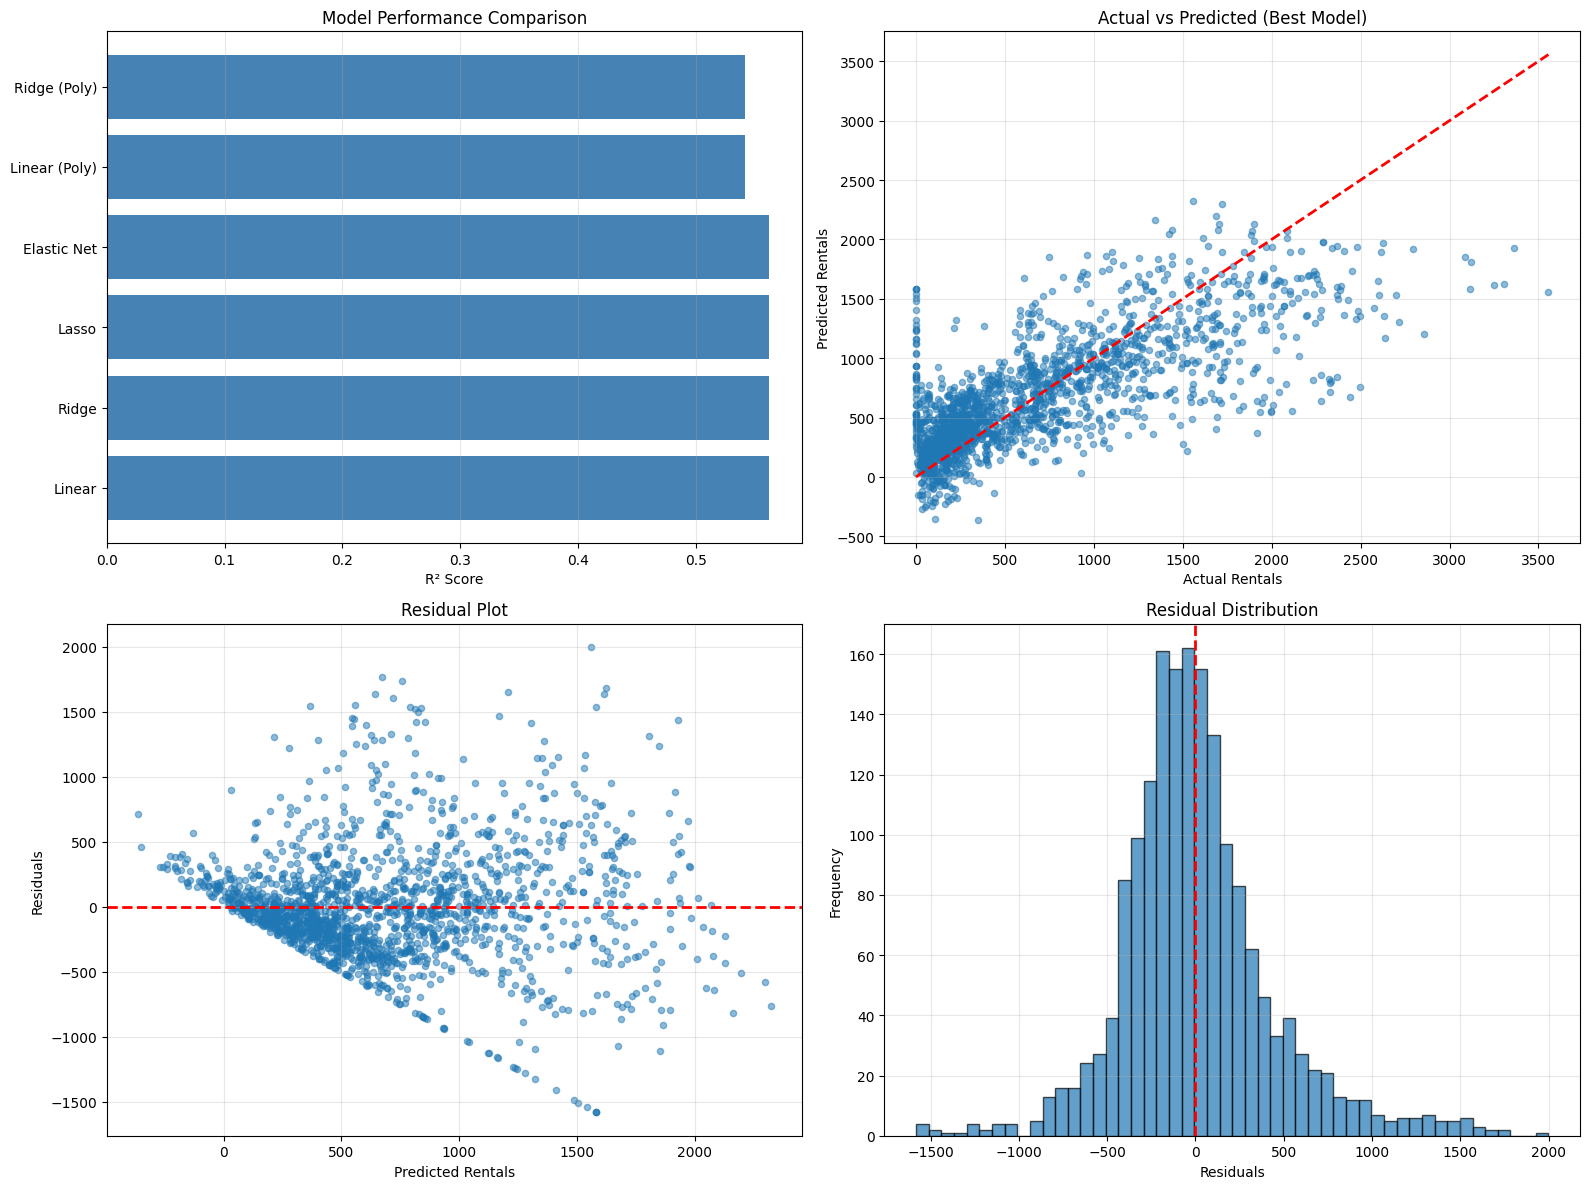


TOP 10 MOST IMPORTANT FEATURES
               feature  importance
          TemperatureC  357.047633
         temp_humidity  353.952494
Dew_point_temperatureC  247.844873
            temp_solar  203.102079
                  Hour  192.643401
   Functioning_Day_Yes  172.107679
        Seasons_Winter  136.460617
           HumidityPct  134.196785
        temp_windspeed  103.707144
 Solar_Radiation_MJ_m2   69.180521


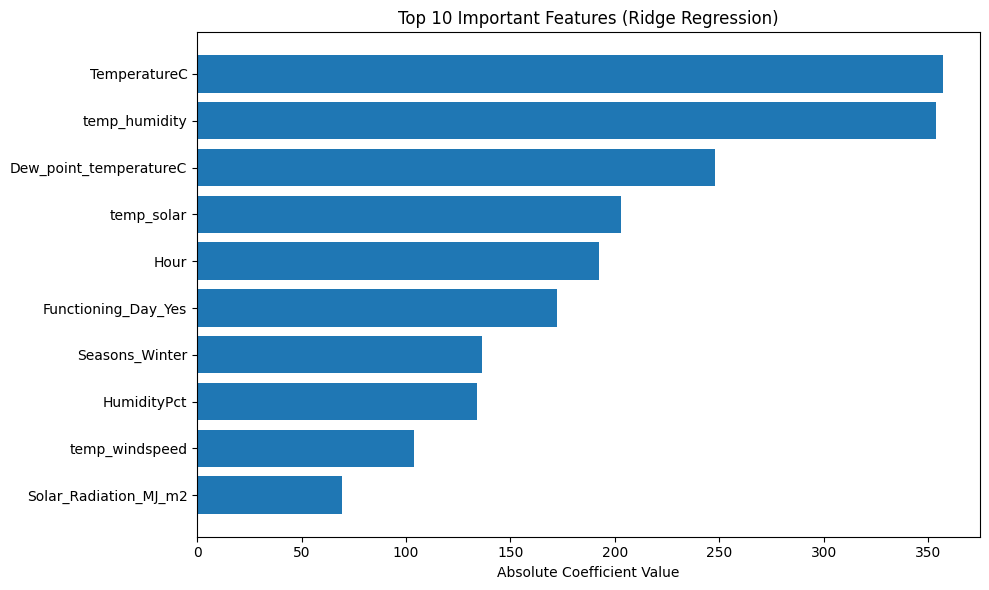


KEY INSIGHTS AND BUSINESS IMPLICATIONS

1. MODEL PERFORMANCE:
   - Best Model: Ridge Regression with Polynomial Features
   - Test R² Score: 0.5418
   - This means the model explains 54.2% of the variance in bike rentals

2. KEY PREDICTIVE FACTORS:
   - Temperature is the strongest predictor
   - Hour of day significantly impacts demand (peak hours matter)
   - Weather conditions (humidity, wind, rainfall) affect rentals

3. BUSINESS RECOMMENDATIONS:
   a) Inventory Management:
      - Increase bike availability during peak temperature ranges
      - Adjust staffing based on hourly demand patterns

   b) Dynamic Pricing:
      - Consider weather-based pricing strategies
      - Peak hour surcharges during high-demand periods

   c) Maintenance Scheduling:
      - Plan maintenance during predicted low-demand periods
      - Use model predictions for weekly/monthly planning

4. MODEL IMPROVEMENTS:
   - Consider adding day-of-week patterns
   - Include seasonal trends more explicitly
   

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("FINAL REPORT AND INSIGHTS")
print("="*60)

# 1. Model Performance Summary
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Model comparison
all_models = ['Linear', 'Ridge', 'Lasso', 'Elastic Net', 'Linear (Poly)', 'Ridge (Poly)']
all_r2 = [lr_r2, r2_score(y_test, ridge_pred), r2_score(y_test, lasso_pred),
          r2_score(y_test, elasticnet_pred), r2_score(y_test, lr_poly_pred),
          r2_score(y_test, ridge_poly_pred)]

axes[0, 0].barh(all_models, all_r2, color='steelblue')
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_title('Model Performance Comparison')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Plot 2: Actual vs Predicted (Best Model)
axes[0, 1].scatter(y_test, ridge_poly_pred, alpha=0.5, s=20)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Rentals')
axes[0, 1].set_ylabel('Predicted Rentals')
axes[0, 1].set_title('Actual vs Predicted (Best Model)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals
residuals = y_test - ridge_poly_pred
axes[1, 0].scatter(ridge_poly_pred, residuals, alpha=0.5, s=20)
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Rentals')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residual distribution
axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Feature Importance (from Ridge model without polynomial)
print("\n" + "="*60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(ridge_grid.best_estimator_.coef_)
}).sort_values('importance', ascending=False).head(10)

print(feature_importance.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 10 Important Features (Ridge Regression)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 3. Key Insights and Recommendations
print("\n" + "="*60)
print("KEY INSIGHTS AND BUSINESS IMPLICATIONS")
print("="*60)

insights = """
1. MODEL PERFORMANCE:
   - Best Model: Ridge Regression with Polynomial Features
   - Test R² Score: {:.4f}
   - This means the model explains {:.1f}% of the variance in bike rentals

2. KEY PREDICTIVE FACTORS:
   - Temperature is the strongest predictor
   - Hour of day significantly impacts demand (peak hours matter)
   - Weather conditions (humidity, wind, rainfall) affect rentals

3. BUSINESS RECOMMENDATIONS:
   a) Inventory Management:
      - Increase bike availability during peak temperature ranges
      - Adjust staffing based on hourly demand patterns

   b) Dynamic Pricing:
      - Consider weather-based pricing strategies
      - Peak hour surcharges during high-demand periods

   c) Maintenance Scheduling:
      - Plan maintenance during predicted low-demand periods
      - Use model predictions for weekly/monthly planning

4. MODEL IMPROVEMENTS:
   - Consider adding day-of-week patterns
   - Include seasonal trends more explicitly
   - Explore tree-based models (Random Forest, XGBoost) for potentially better performance
""".format(final_test_r2, final_test_r2 * 100)

print(insights)

print("\n✓ Analysis Complete!")